# Pipeline Completa

In [7]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

import numpy as np
import pandas as pd
import random
import torch
import torch.utils.data as data
from torchvision.utils import save_image
from src.baseline.model import BaselineCNN
from src.baseline.train import train_model
from src.baseline.evaluate import ClassificationEvaluator
from src.utils.save_exp import save_experiment
from src.utils.data_loader import ButterflyDataset
from src.config import TARGET_CLASSES

def run_complete_pipeline(
    model_name,              # Nome do experimento: 'raw', 'cvae', 'ddpm', etc.
    model_generativo,        # O teu modelo treinado (CVAE, AE, etc.) OU None se for para o 'raw'
    generate_count_map,      # O GENERATE_COUNT_MAP do config.py
    val_df,                  # DataFrame do split de validação original
    test_df,                 # DataFrame do split de teste original
    img_dir_reais,           # Pasta das imagens reais ('../data/raw/train')
    data_transform,          # As transformações do torchvision
    num_classes,             # C
    class_names,             # Lista de nomes das classes
    device,                  # torch.device
    seeds=[42, 100, 2024, 777, 999],
    epochs=100,
    batch_size=32,
    base_output_dir='../src/baseline'
):

    experiment_dir = os.path.join(base_output_dir, f"saved_augmented_{model_name}")
    os.makedirs(experiment_dir, exist_ok=True)
    
    base_augmented_dir = f'../data/augmented/{model_name}'
    csv_treino_final_path = os.path.join(base_augmented_dir, 'train_augmented.csv')

    # --- DATASET AUGMENTED---
    if model_generativo is None or model_name.lower() == 'raw':
        print(f"[RAW]")
        csv_original_path = '../data/raw/train.csv' if os.path.exists('../data/raw/train.csv') else '../data/train.csv'
        train_df_final = pd.read_csv(csv_original_path)
    else:
        print(f"[AUGMENTED] {model_name.upper()}")

        csv_original_path = '../data/raw/train.csv' if os.path.exists('../data/raw/train.csv') else '../data/train.csv'
        df_original = pd.read_csv(csv_original_path)
        novas_linhas = []

        for class_name in TARGET_CLASSES:
            class_folder = os.path.join(base_augmented_dir, class_name)
            if os.path.exists(class_folder):
                for img_name in os.listdir(class_folder):
                    if img_name.endswith('.png'):
                        novas_linhas.append({
                            'filename': os.path.join(class_folder, img_name), 
                            'label': class_name,
                        })

        df_augmented = pd.DataFrame(novas_linhas)
        train_df_final = pd.concat([df_original, df_augmented], ignore_index=True)
        os.makedirs(base_augmented_dir, exist_ok=True)
        train_df_final.to_csv(csv_treino_final_path, index=False)
        print(f"CSV estendido guardado em: {csv_treino_final_path} (Total: {len(train_df_final)} imagens)")

    # --- Dataloaders ---
    train_dataset = ButterflyDataset(df=train_df_final, img_dir=img_dir_reais, transform=data_transform)
    train_dataloader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = ButterflyDataset(df=val_df, img_dir=img_dir_reais, transform=data_transform)
    val_dataloader = data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    test_dataset = ButterflyDataset(df=test_df, img_dir=img_dir_reais, transform=data_transform)
    test_dataloader = data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # --- Seed Loop ---
    macro_f1_scores = []
    accuracy_scores = []

    for i, seed in enumerate(seeds):
        print(f"\n" + "="*60)
        print(f"🏃 RUN [{model_name.upper()}] - Seed {seed} ({i+1}/{len(seeds)})")
        print("="*60)
        
        # Garante o determinismo da run atual
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        
        seed_output_dir = os.path.join(experiment_dir, f"seed_{seed}")
        os.makedirs(seed_output_dir, exist_ok=True)
        weight_path = os.path.join(seed_output_dir, 'model_weights.pth')
        
        # Reinicializa a rede CNN do zero
        model_classifier = BaselineCNN(num_classes=num_classes).to(device)
        
        config_exp = {
            "experiment_type": model_name,
            "batch_size": batch_size,
            "epochs": epochs,
            "seed": seed
        }
        
        print("A treinar o classificador...")
        model_classifier, history_augmented = train_model(   
            train_loader=train_dataloader,
            val_loader=val_dataloader,
            epochs=epochs,
            device=device,
            n_classes=num_classes
        )
        
        torch.save(model_classifier.state_dict(), weight_path)
        save_path = save_experiment(model_classifier, history_augmented, config_exp, seed_output_dir)
        
        print("A avaliar no conjunto de teste...")
        model_classifier.eval()
        y_true, y_pred = [], []
        
        with torch.no_grad():
            for images, labels in test_dataloader:
                images = images.to(device)
                outputs = model_classifier(images)
                _, preds = torch.max(outputs, 1)
                y_true.extend(labels.numpy())
                y_pred.extend(preds.cpu().numpy())
                
        y_true, y_pred = np.array(y_true), np.array(y_pred)
        
        ev_raw = ClassificationEvaluator(class_names=class_names, n_classes=num_classes)
        ev_raw.update(y_true, y_pred)
        report = ev_raw.compute()
        
        if 'macro' in report and 'f1_macro' in report['macro']:
            macro_f1_scores.append(report['macro']['f1_macro'])
        if 'accuracy' in report:
            accuracy_scores.append(report['accuracy'])
            
        ev_raw.plot_confusion_matrix(report, save_path=os.path.join(save_path, 'confusion_matrix.png'))
        with open(os.path.join(save_path, 'classification_report.txt'), 'w', encoding='utf-8') as f:
            f.write(str(report))
            
        print(f"Run concluída. Resultados guardados em: {save_path}")

    # --- Resultado Global ---
    print("\n" + "="*60)
    print(f"RESUMO ESTATÍSTICO FINAL ({model_name.upper()})")
    print("="*60)
    acc_mean, acc_std = np.mean(accuracy_scores), np.std(accuracy_scores)
    f1_mean, f1_std = np.mean(macro_f1_scores), np.std(macro_f1_scores)
    print(f"Accuracy Média: {acc_mean:.4f} ± {acc_std:.4f}")
    print(f"Macro F1-Score Médio: {f1_mean:.4f} ± {f1_std:.4f}")
    
    return {"model": model_name, "acc": (acc_mean, acc_std), "f1": (f1_mean, f1_std)}

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working on {DEVICE}.")

Working on cuda.


In [4]:
import pandas as pd
import torchvision.transforms as transforms
from src.config import GENERATE_COUNT_MAP

# Splits reais e fixos do projeto
val_df = pd.read_csv('splits/val_split.csv')
test_df = pd.read_csv('splits/test_split.csv')
class_names = sorted(test_df['label'].unique().tolist())

BATCH_SIZE = 32
IMAGE_SIZE = 64

data_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])
img_dir_reais = "../data/raw/train"

# 0. Raw

[RAW]

🏃 RUN [RAW] - Seed 42 (1/5)
A treinar o classificador...
Epoch 1/100 -> Train Loss: 4.1065 | Train Acc: 0.0333 || Val Loss: 3.9267 | Val Acc: 0.0480
Epoch 2/100 -> Train Loss: 3.7431 | Train Acc: 0.0598 || Val Loss: 3.4675 | Val Acc: 0.0801
Epoch 3/100 -> Train Loss: 3.5450 | Train Acc: 0.0829 || Val Loss: 3.5371 | Val Acc: 0.0861
Epoch 4/100 -> Train Loss: 3.4020 | Train Acc: 0.0992 || Val Loss: 3.1566 | Val Acc: 0.1331
Epoch 5/100 -> Train Loss: 3.2803 | Train Acc: 0.1144 || Val Loss: 2.9896 | Val Acc: 0.1652
Epoch 6/100 -> Train Loss: 3.1677 | Train Acc: 0.1306 || Val Loss: 2.8694 | Val Acc: 0.2012
Epoch 7/100 -> Train Loss: 3.0558 | Train Acc: 0.1473 || Val Loss: 2.6995 | Val Acc: 0.2372
Epoch 8/100 -> Train Loss: 2.9515 | Train Acc: 0.1662 || Val Loss: 2.6302 | Val Acc: 0.2533
Epoch 9/100 -> Train Loss: 2.8405 | Train Acc: 0.1872 || Val Loss: 2.5162 | Val Acc: 0.2593
Epoch 10/100 -> Train Loss: 2.7095 | Train Acc: 0.2214 || Val Loss: 2.6145 | Val Acc: 0.2372
Epoch 11/100 ->

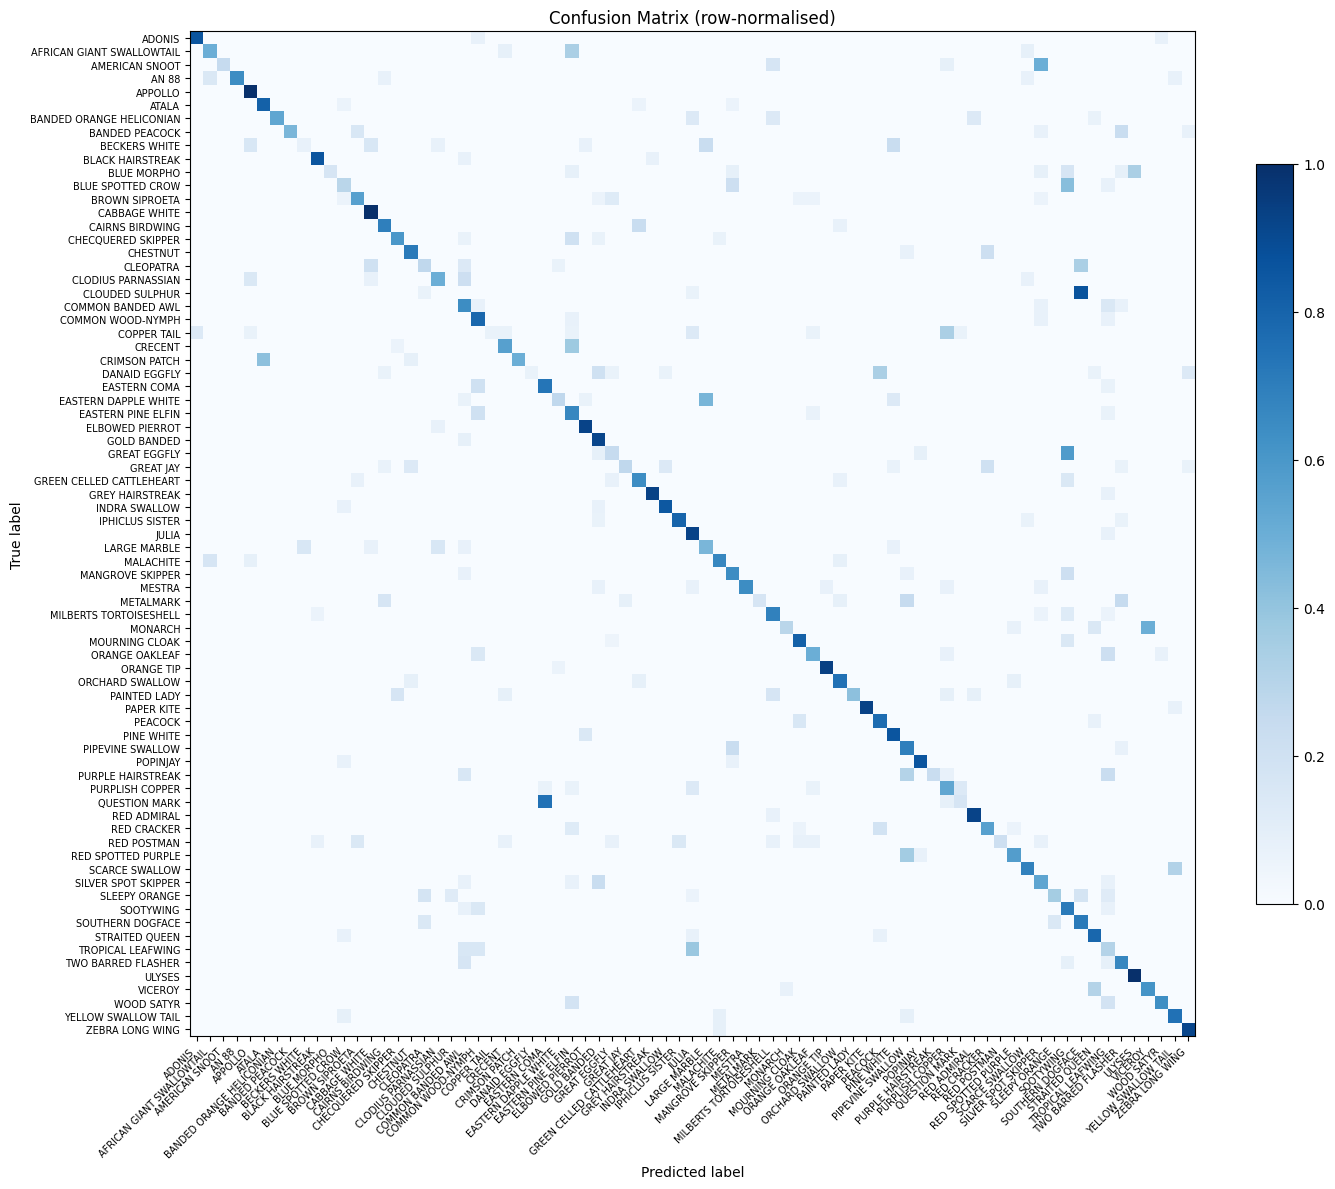

Run concluída. Resultados guardados em: ../src/baseline/saved_augmented_raw/seed_42/run_20260601_195952

🏃 RUN [RAW] - Seed 100 (2/5)
A treinar o classificador...
Epoch 1/100 -> Train Loss: 4.1321 | Train Acc: 0.0290 || Val Loss: 3.8567 | Val Acc: 0.0511
Epoch 2/100 -> Train Loss: 3.8039 | Train Acc: 0.0515 || Val Loss: 3.5884 | Val Acc: 0.0641
Epoch 3/100 -> Train Loss: 3.6038 | Train Acc: 0.0714 || Val Loss: 3.4104 | Val Acc: 0.0841
Epoch 4/100 -> Train Loss: 3.4905 | Train Acc: 0.0877 || Val Loss: 3.1525 | Val Acc: 0.1321
Epoch 5/100 -> Train Loss: 3.3369 | Train Acc: 0.1012 || Val Loss: 3.0737 | Val Acc: 0.1481
Epoch 6/100 -> Train Loss: 3.2491 | Train Acc: 0.1075 || Val Loss: 3.0394 | Val Acc: 0.1171
Epoch 7/100 -> Train Loss: 3.1460 | Train Acc: 0.1281 || Val Loss: 2.8865 | Val Acc: 0.1942
Epoch 8/100 -> Train Loss: 3.0286 | Train Acc: 0.1548 || Val Loss: 2.8065 | Val Acc: 0.2042
Epoch 9/100 -> Train Loss: 2.9124 | Train Acc: 0.1850 || Val Loss: 2.8486 | Val Acc: 0.1922
Epoch 10/

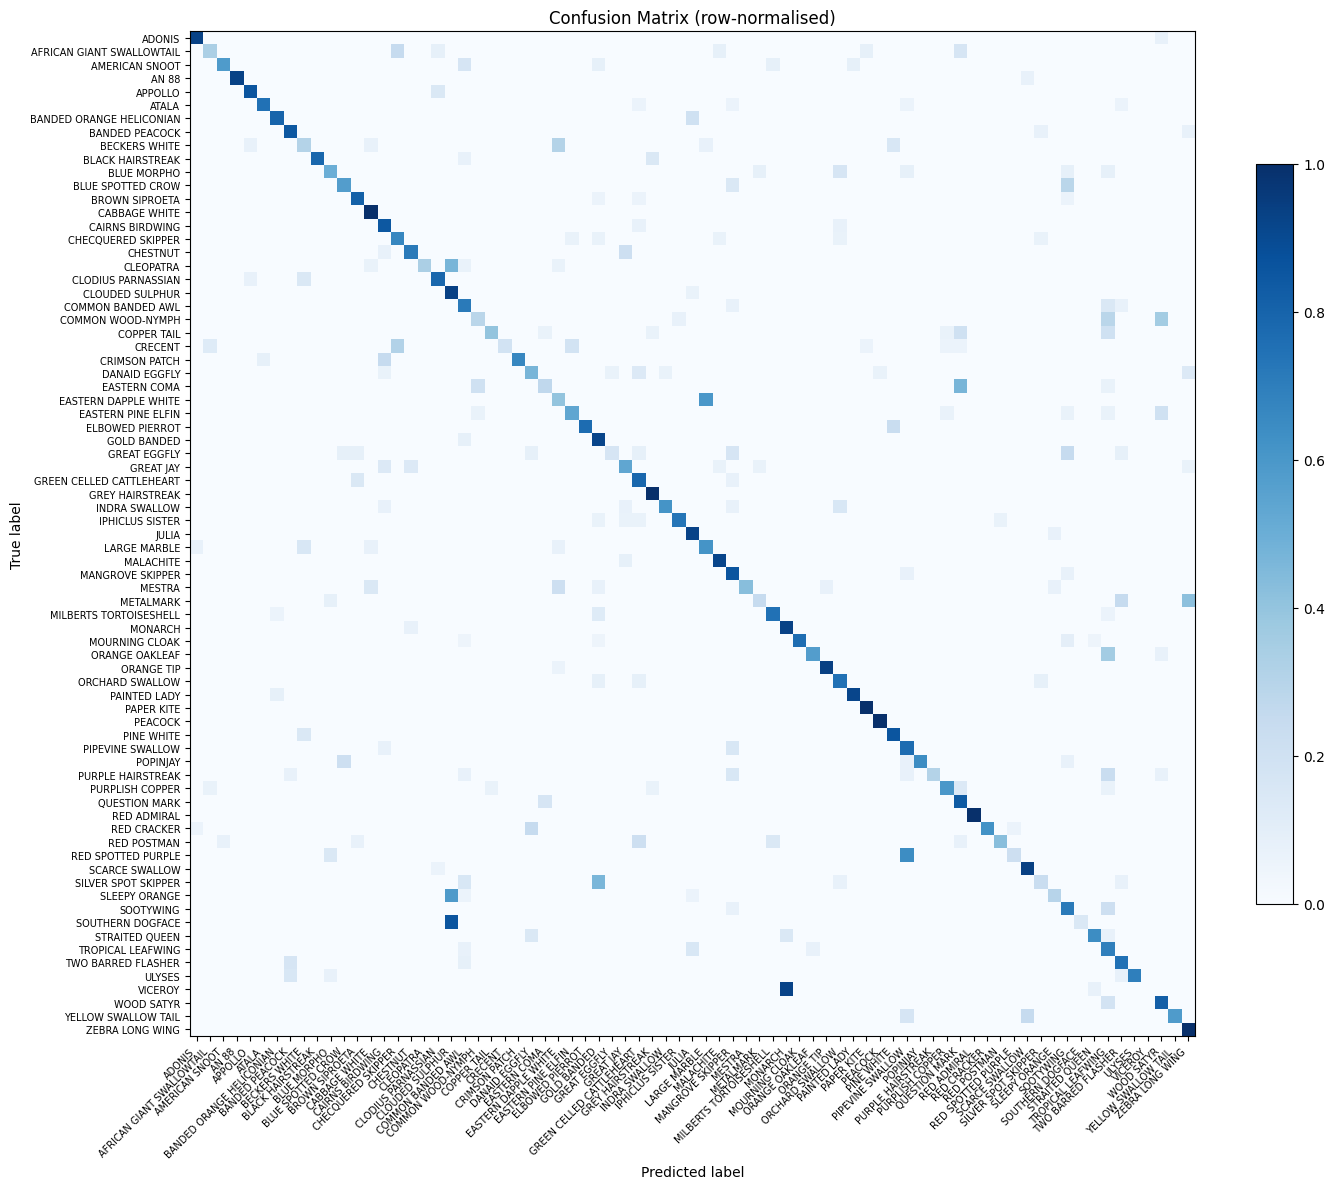

Run concluída. Resultados guardados em: ../src/baseline/saved_augmented_raw/seed_100/run_20260601_200749

🏃 RUN [RAW] - Seed 2024 (3/5)
A treinar o classificador...
Epoch 1/100 -> Train Loss: 4.1292 | Train Acc: 0.0364 || Val Loss: 3.9444 | Val Acc: 0.0581
Epoch 2/100 -> Train Loss: 3.8473 | Train Acc: 0.0448 || Val Loss: 3.6913 | Val Acc: 0.0721
Epoch 3/100 -> Train Loss: 3.6134 | Train Acc: 0.0712 || Val Loss: 3.3272 | Val Acc: 0.1171
Epoch 4/100 -> Train Loss: 3.3638 | Train Acc: 0.1091 || Val Loss: 3.0577 | Val Acc: 0.1281
Epoch 5/100 -> Train Loss: 3.2047 | Train Acc: 0.1256 || Val Loss: 2.8616 | Val Acc: 0.1842
Epoch 6/100 -> Train Loss: 3.0528 | Train Acc: 0.1535 || Val Loss: 2.7524 | Val Acc: 0.1852
Epoch 7/100 -> Train Loss: 2.9367 | Train Acc: 0.1623 || Val Loss: 2.6299 | Val Acc: 0.2412
Epoch 8/100 -> Train Loss: 2.8567 | Train Acc: 0.1750 || Val Loss: 2.5581 | Val Acc: 0.2663
Epoch 9/100 -> Train Loss: 2.7204 | Train Acc: 0.2089 || Val Loss: 2.6205 | Val Acc: 0.2342
Epoch 1

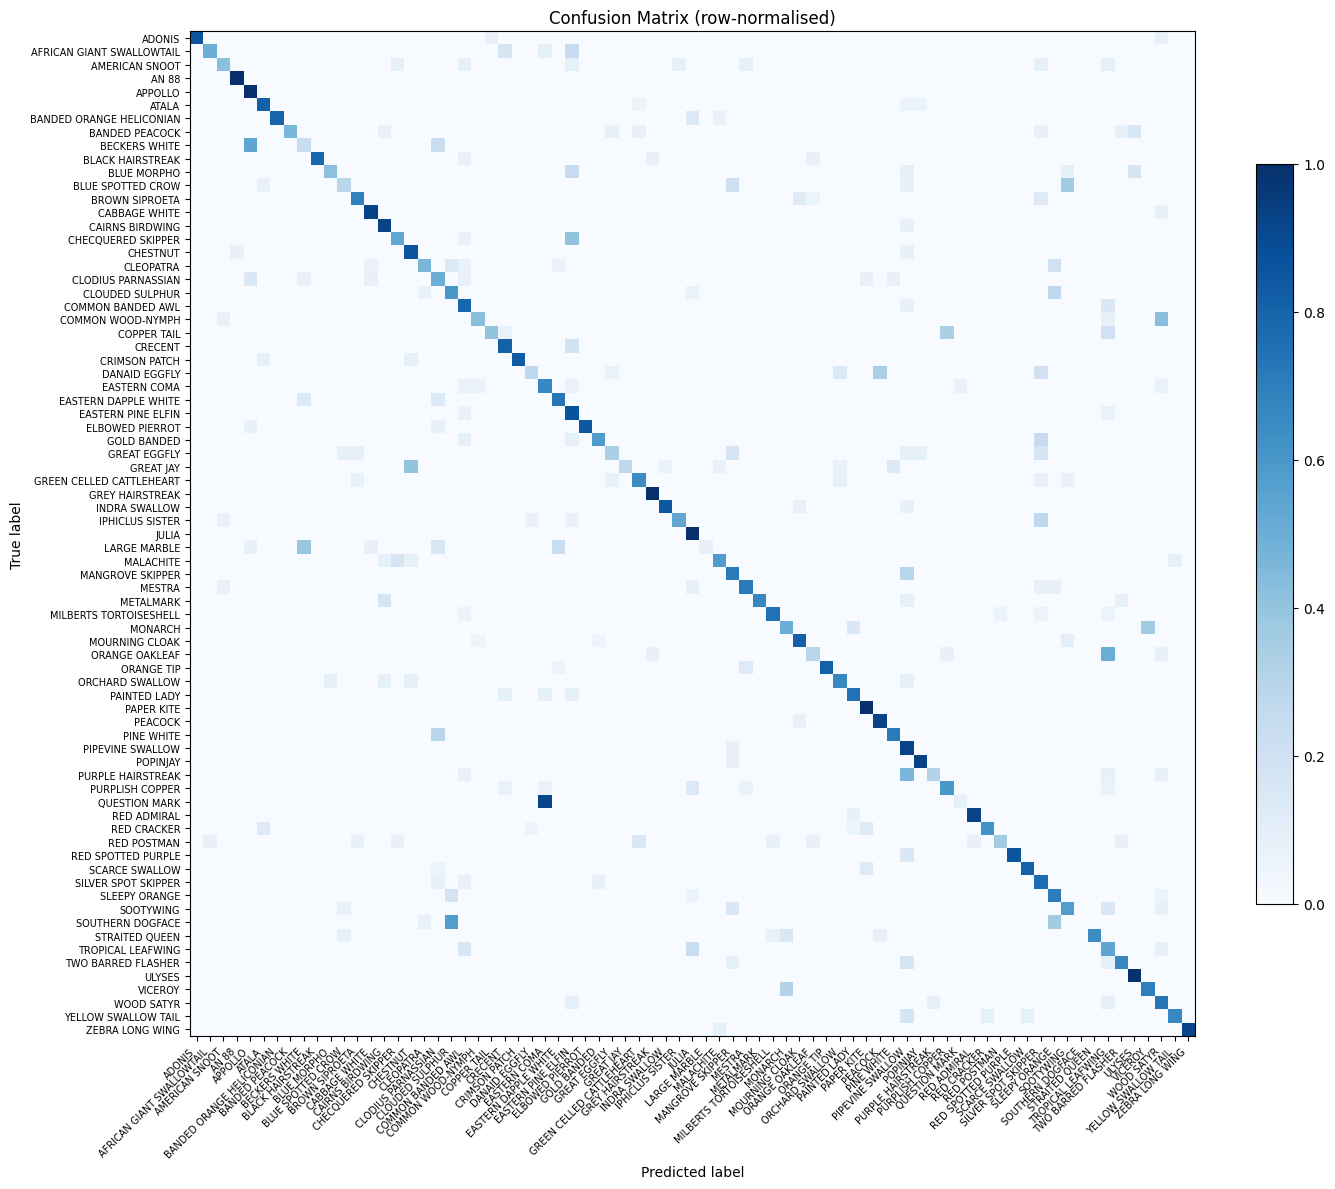

Run concluída. Resultados guardados em: ../src/baseline/saved_augmented_raw/seed_2024/run_20260601_201417

🏃 RUN [RAW] - Seed 777 (4/5)
A treinar o classificador...
Epoch 1/100 -> Train Loss: 4.1505 | Train Acc: 0.0304 || Val Loss: 3.8978 | Val Acc: 0.0440
Epoch 2/100 -> Train Loss: 3.7638 | Train Acc: 0.0514 || Val Loss: 3.5050 | Val Acc: 0.0821
Epoch 3/100 -> Train Loss: 3.5628 | Train Acc: 0.0744 || Val Loss: 3.2592 | Val Acc: 0.1111
Epoch 4/100 -> Train Loss: 3.4168 | Train Acc: 0.0975 || Val Loss: 3.2744 | Val Acc: 0.1251
Epoch 5/100 -> Train Loss: 3.3237 | Train Acc: 0.1066 || Val Loss: 3.3222 | Val Acc: 0.1071
Epoch 6/100 -> Train Loss: 3.1595 | Train Acc: 0.1383 || Val Loss: 2.9847 | Val Acc: 0.1552
Epoch 7/100 -> Train Loss: 3.0842 | Train Acc: 0.1425 || Val Loss: 2.7753 | Val Acc: 0.2262
Epoch 8/100 -> Train Loss: 2.9460 | Train Acc: 0.1795 || Val Loss: 2.6213 | Val Acc: 0.2583
Epoch 9/100 -> Train Loss: 2.8629 | Train Acc: 0.1958 || Val Loss: 2.5595 | Val Acc: 0.2563
Epoch 1

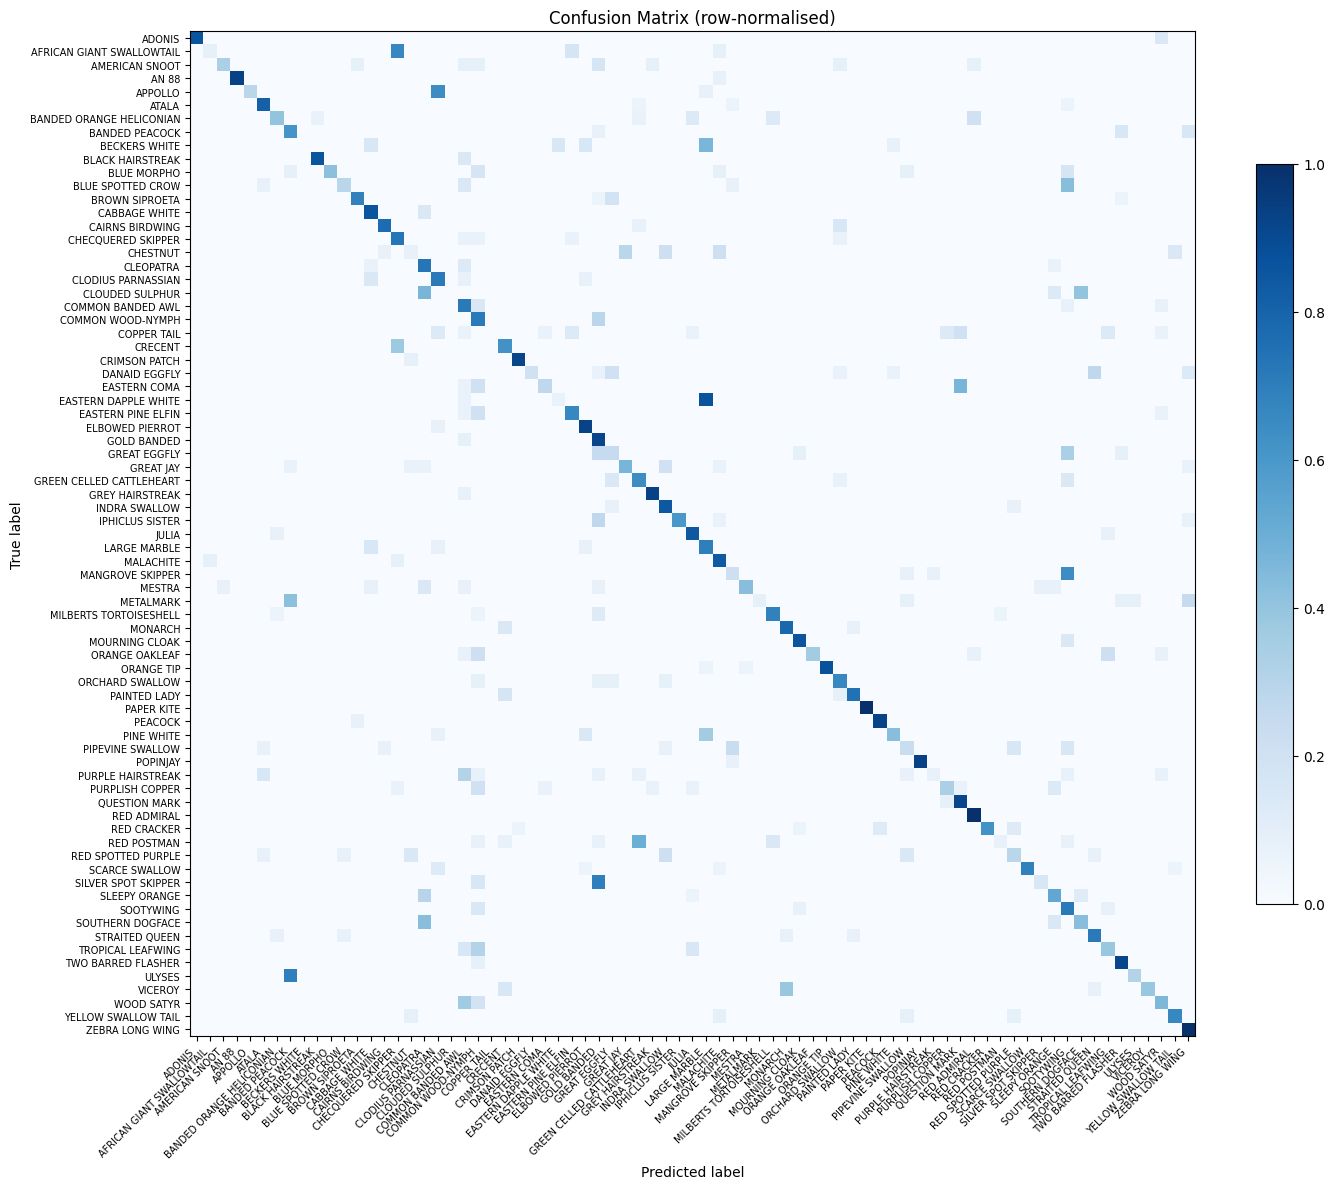

Run concluída. Resultados guardados em: ../src/baseline/saved_augmented_raw/seed_777/run_20260601_201932

🏃 RUN [RAW] - Seed 999 (5/5)
A treinar o classificador...
Epoch 1/100 -> Train Loss: 4.1427 | Train Acc: 0.0342 || Val Loss: 3.8853 | Val Acc: 0.0521
Epoch 2/100 -> Train Loss: 3.7919 | Train Acc: 0.0606 || Val Loss: 3.8229 | Val Acc: 0.0651
Epoch 3/100 -> Train Loss: 3.5593 | Train Acc: 0.0773 || Val Loss: 3.3178 | Val Acc: 0.1021
Epoch 4/100 -> Train Loss: 3.3819 | Train Acc: 0.0979 || Val Loss: 3.3546 | Val Acc: 0.1121
Epoch 5/100 -> Train Loss: 3.2523 | Train Acc: 0.1166 || Val Loss: 3.1168 | Val Acc: 0.1341
Epoch 6/100 -> Train Loss: 3.1349 | Train Acc: 0.1337 || Val Loss: 2.8429 | Val Acc: 0.1902
Epoch 7/100 -> Train Loss: 3.0175 | Train Acc: 0.1621 || Val Loss: 2.7100 | Val Acc: 0.2152
Epoch 8/100 -> Train Loss: 2.8807 | Train Acc: 0.1848 || Val Loss: 2.5648 | Val Acc: 0.2623
Epoch 9/100 -> Train Loss: 2.7711 | Train Acc: 0.2033 || Val Loss: 2.3817 | Val Acc: 0.2733
Epoch 10

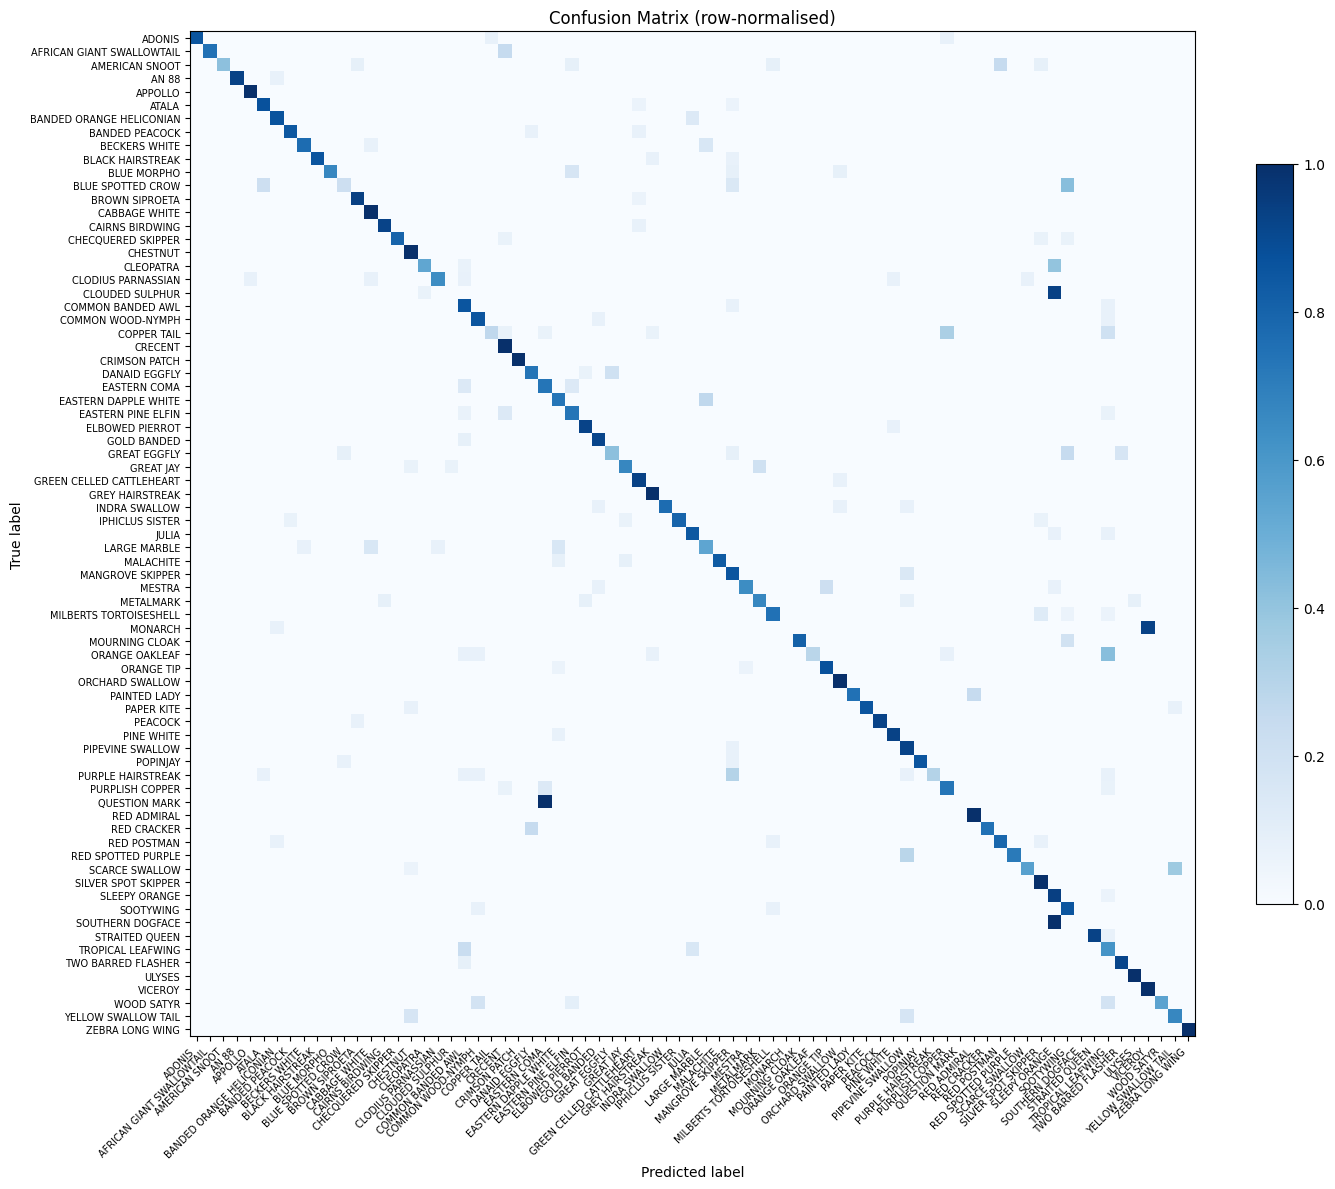

Run concluída. Resultados guardados em: ../src/baseline/saved_augmented_raw/seed_999/run_20260601_202805

RESUMO ESTATÍSTICO FINAL (RAW)
Accuracy Média: 0.6440 ± 0.0619
Macro F1-Score Médio: nan ± nan


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [5]:
resultados_raw = run_complete_pipeline(
    model_name='raw',
    model_generativo=None,
    generate_count_map=None,
    val_df=val_df, test_df=test_df,
    img_dir_reais=img_dir_reais, data_transform=data_transform,
    num_classes=len(class_names), class_names=class_names, device=DEVICE,
    epochs=100
)

In [9]:
import os
import re
import numpy as np

# Caminho para a pasta do experimento
experiment_dir = '../src/baseline/saved_augmented_raw'

macro_f1_scores = []
accuracy_scores = []

if os.path.exists(experiment_dir):
    seeds_folders = [f for f in os.listdir(experiment_dir) if f.startswith('seed_')]
    
    for seed_folder in seeds_folders:
        seed_path = os.path.join(experiment_dir, seed_folder)
        
        # Percorre a estrutura de pastas até encontrar o classification_report.txt
        for root, dirs, files in os.walk(seed_path):
            if 'classification_report.txt' in files:
                report_path = os.path.join(root, 'classification_report.txt')
                
                with open(report_path, 'r', encoding='utf-8') as f:
                    content = f.read()
                
                # 1. Procurar a Accuracy usando Expressões Regulares
                # Procura por: 'accuracy': seguido de um número decimal
                acc_match = re.search(r"'accuracy':\s*([0-9.]+)", content)
                
                # 2. Procurar o F1-Macro
                # Procura por: 'f1_macro': seguido de um número decimal
                f1_match = re.search(r"'f1_macro':\s*([0-9.]+)", content)
                
                if acc_match and f1_match:
                    accuracy_scores.append(float(acc_match.group(1)))
                    macro_f1_scores.append(float(f1_match.group(1)))
                    print(f"✅ Seed {seed_folder.split('_')[1]} recuperada -> Acc: {acc_match.group(1)} | F1: {f1_match.group(1)}")
                else:
                    # Se as chaves tiverem sido salvas no formato impresso da tabela (print_report)
                    # Tentamos o plano B de captura por colunas de texto
                    acc_backup = re.search(r"Overall Accuracy:\s*([0-9.]+)", content)
                    f1_backup = re.search(r"Macro avg\s+[0-9.]+\s+[0-9.]+\s+([0-9.]+)", content)
                    
                    if acc_backup and f1_backup:
                        accuracy_scores.append(float(acc_backup.group(1)))
                        macro_f1_scores.append(float(f1_backup.group(1)))
                        print(f"✅ Seed {seed_folder.split('_')[1]} recuperada (Tabela) -> Acc: {acc_backup.group(1)} | F1: {f1_backup.group(1)}")
                    else:
                        print(f"⚠️ Encontrado ficheiro em {seed_folder}, mas falhou a extração dos valores.")

# --- RESUMO FINAL ---
print("\n" + "=" * 60)
print(f"📊 RESUMO ESTATÍSTICO RECUPERADO ({os.path.basename(experiment_dir).replace('saved_augmented_', '').upper()})")
print("=" * 60)

if accuracy_scores and macro_f1_scores:
    print(f"Número de Seeds processadas: {len(accuracy_scores)}")
    print(f"Accuracy Média: {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
    print(f"Macro F1-Score Médio: {np.mean(macro_f1_scores):.4f} ± {np.std(macro_f1_scores):.4f}")
else:
    print("❌ Não foi possível extrair os dados. Garante que os ficheiros contêm texto legível.")

✅ Seed 777 recuperada -> Acc: 0.5663461538461538 | F1: 0.5425404888779144
✅ Seed 42 recuperada -> Acc: 0.5951923076923077 | F1: 0.577040566275359
✅ Seed 999 recuperada -> Acc: 0.7461538461538462 | F1: 0.7319304727471909
✅ Seed 100 recuperada -> Acc: 0.6538461538461539 | F1: 0.6415002648480846
✅ Seed 2024 recuperada -> Acc: 0.6586538461538461 | F1: 0.649206316956928

📊 RESUMO ESTATÍSTICO RECUPERADO (RAW)
Número de Seeds processadas: 5
Accuracy Média: 0.6440 ± 0.0619
Macro F1-Score Médio: 0.6284 ± 0.0653


# 1.1 cVAE

In [ ]:
resultados_cvae = run_complete_pipeline(
    model_name='cvae',
    model_generativo='cvae',
    generate_count_map=GENERATE_COUNT_MAP,
    val_df=val_df, test_df=test_df,
    img_dir_reais=img_dir_reais, data_transform=data_transform,
    num_classes=len(class_names), class_names=class_names, device=DEVICE,
    epochs=100
)

# 1.2 beta cVAE

In [ ]:
resultados_beta_cvae = run_complete_pipeline(
    model_name='beta4_vae',
    model_generativo = 'beta4_vae',
    generate_count_map=GENERATE_COUNT_MAP,
    val_df=val_df, test_df=test_df,
    img_dir_reais=img_dir_reais, data_transform=data_transform,
    num_classes=len(class_names), class_names=class_names, device=DEVICE,
    epochs=100
)

# 2. GANs

# 3. Diff

In [ ]:
resultados_diff = run_complete_pipeline(
    model_name='diffusion',
    model_generativo='diffusion',
    generate_count_map=GENERATE_COUNT_MAP,
    val_df=val_df, test_df=test_df,
    img_dir_reais=img_dir_reais, data_transform=data_transform,
    num_classes=len(class_names), class_names=class_names, device=DEVICE,
    epochs=100
)